In [1]:
from pathlib import Path
from textalloc import allocate
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import yaml

from _configs.country_config import *
from _configs.files_config import *
from _configs.run_config import *

from _utils.utils import *

In [2]:
input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_validation.yml").read_text(encoding="utf-8"))
# input_data = yaml.safe_load((Path(VALIDATION_RUN_INPUTS_DIR)/"input_population_bins_beta_zero_pop_0.25.yml").read_text(encoding="utf-8"))


population_scale_from_input_yml = input_data["population_demographic"]["artificial_rescaling_of_population_size"]
starting_date = input_data["simulation_timeframe"]["starting_date"]
birth_rate_from_config = input_data["population_demographic"]["birth_rate"]
public_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][0]
private_pct = input_data["strategy_parameters"]["strategy_db"][8]["start_distribution"][1]

print(f"Population scale: {population_scale_from_input_yml}")
print(f"Starting date: {starting_date}")
print(f"Birth rate: {birth_rate_from_config}")
print(f"Public percentage: {public_pct}")
print(f"Private percentage: {private_pct}")

# 1) Use the original dict
country_dict = {
    "population_scale": population_scale_from_input_yml,
    }
country_json = json.dumps(country_dict, ensure_ascii=False)
# 3) Attribute-style access (SimpleNamespace)
from types import SimpleNamespace
country = json.loads(country_json, object_hook=lambda d: SimpleNamespace(**d))

exp_path = validation_path
output_path = Path(exp_path) / "output"
analysis_path = Path(exp_path) / "analysis"
os.makedirs(analysis_path, exist_ok=True)

print("\ndata_path:", data_path)
print("output_path:", output_path)
print("analysis_path:", analysis_path)

Population scale: 0.25
Starting date: 2011/1/1
Birth rate: 0.0335
Public percentage: 0.445
Private percentage: 0.555

data_path: DATA
output_path: validation_runs/validation_init_pop_21.12M.asc_0.25_population_scale_one_pattern_20_replicates/output
analysis_path: validation_runs/validation_init_pop_21.12M.asc_0.25_population_scale_one_pattern_20_replicates/analysis


## PfPR

In [3]:
output_path_obj = Path(output_path)
if not output_path_obj.exists() or not output_path_obj.is_dir():
    raise NotADirectoryError(f"Path {output_path} is not a valid directory.")
db_files = list(output_path_obj.glob("*.db"))
if len(db_files) == 0:
    raise FileNotFoundError(f"No .db files found in directory {output_path}.")

agg_population = pd.DataFrame(columns=["monthly_data_id", "unit_id", "population"])
agg_treatment = pd.DataFrame(columns=["monthly_data_id", "unit_id", "treatments"])
agg_clinical_episodes = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes"])
agg_prevalence_2_to_10 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "pfpr_2to10"])
agg_clinical_episodes_2_to_10 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes_2_to_10"])
agg_prevalence_under_5 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "pfpr_under5"])
agg_clinical_episodes_under_5 = pd.DataFrame(columns=["monthly_data_id", "unit_id", "clinical_episodes_under5"])

rep = 0
for file in output_path_obj.glob("*.db"):
    data = get_table(file, "monthly_site_data_district")
    clinical_episodes_2_to_10 = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
            "clinical_episodes_by_age_class_5_6",
            "clinical_episodes_by_age_class_6_7",
            "clinical_episodes_by_age_class_7_8",
            "clinical_episodes_by_age_class_8_9",
            "clinical_episodes_by_age_class_9_10",
        ]
    ].copy()
    clinical_episodes_2_to_10["clinical_episodes_2_to_10"] = clinical_episodes_2_to_10[
        [
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
            "clinical_episodes_by_age_class_5_6",
            "clinical_episodes_by_age_class_6_7",
            "clinical_episodes_by_age_class_7_8",
            "clinical_episodes_by_age_class_8_9",
            "clinical_episodes_by_age_class_9_10",
        ]
    ].sum(axis=1)
    clinical_episodes_under_5 = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes_by_age_class_0_1",
            "clinical_episodes_by_age_class_1_2",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
        ]
    ].copy()
    clinical_episodes_under_5["clinical_episodes_under5"] = clinical_episodes_under_5[
        [
            "clinical_episodes_by_age_class_0_1",
            "clinical_episodes_by_age_class_1_2",
            "clinical_episodes_by_age_class_2_3",
            "clinical_episodes_by_age_class_3_4",
            "clinical_episodes_by_age_class_4_5",
        ]
    ].sum(axis=1)
    
    # Add a column to the agg_* data frames from data
    try:
        agg_population = agg_population.merge(
            data[["monthly_data_id", "unit_id", "population"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_treatment = agg_treatment.merge(
            data[["monthly_data_id", "unit_id", "treatments"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_clinical_episodes = agg_clinical_episodes.merge(
            data[["monthly_data_id", "unit_id", "clinical_episodes"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_prevalence_2_to_10 = agg_prevalence_2_to_10.merge(
            data[["monthly_data_id", "unit_id", "pfpr_2to10"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        
        agg_clinical_episodes_2_to_10 = agg_clinical_episodes_2_to_10.merge(
            clinical_episodes_2_to_10[["monthly_data_id", "unit_id", "clinical_episodes_2_to_10"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_prevalence_under_5 = agg_prevalence_under_5.merge(
            data[["monthly_data_id", "unit_id", "pfpr_under5"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
        agg_clinical_episodes_under_5 = agg_clinical_episodes_under_5.merge(
            clinical_episodes_under_5[["monthly_data_id", "unit_id", "clinical_episodes_under5"]].copy(),
            how="outer",
            on=["monthly_data_id", "unit_id"],
            suffixes=("", f"_{rep}"),
        )
    except Exception as e:
        error(f"Error processing replicate {rep}: {e}")
    rep += 1
    
agg_population = agg_population.drop(columns=["population"])
agg_treatment = agg_treatment.drop(columns=["treatments"])
agg_clinical_episodes = agg_clinical_episodes.drop(columns=["clinical_episodes"])
agg_prevalence_2_to_10 = agg_prevalence_2_to_10.drop(columns=["pfpr_2to10"])
agg_clinical_episodes_2_to_10 = agg_clinical_episodes_2_to_10.drop(columns=["clinical_episodes_2_to_10"])
agg_prevalence_under_5 = agg_prevalence_under_5.drop(columns=["pfpr_under5"])
agg_clinical_episodes_under_5 = agg_clinical_episodes_under_5.drop(columns=["clinical_episodes_under5"])

agg_prevalence_2_to_10.to_csv(f"{analysis_path}/agg_prevalence_2_to_10.csv", index=False)
agg_clinical_episodes_2_to_10.to_csv(f"{analysis_path}/agg_clinical_episodes_2_to_10.csv", index=False)
agg_prevalence_under_5.to_csv(f"{analysis_path}/agg_prevalence_under_5.csv", index=False)
agg_clinical_episodes_under_5.to_csv(f"{analysis_path}/agg_clinical_episodes_under_5.csv", index=False)
agg_population.to_csv(f"{analysis_path}/agg_population.csv", index=False)
agg_treatment.to_csv(f"{analysis_path}/agg_treatment.csv", index=False)
agg_clinical_episodes.to_csv(f"{analysis_path}/agg_clinical_episodes.csv", index=False)

In [4]:
# agg_clinical_episodes.tail(24)
agg_clinical_episodes = agg_clinical_episodes.sort_values("unit_id", ascending=False).reset_index(drop=True)
unit_id_to_inspect = 6
agg_clinical_episodes.loc[
    agg_clinical_episodes["unit_id"] == unit_id_to_inspect
].sort_values("monthly_data_id")
agg_clinical_episodes.tail(24)

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
918,87,1,62701,62565,63039,62865,63119,63956,62902,63555,...,63136,62832,63184,63249,63361,63049,63135,63355,63962,63202
919,83,1,69209,69101,69734,69271,69651,69475,69493,69887,...,69181,69553,69317,69355,69457,69260,70028,69283,69474,69317
920,84,1,67415,67352,67629,67038,67360,67338,67510,67339,...,67233,67453,67344,66738,67236,66931,68187,67300,67655,67120
921,80,1,69244,68991,69613,69344,68990,69092,69905,69392,...,69337,69778,68956,68813,69116,69230,69688,68916,69349,69572
922,81,1,69152,69471,69944,68942,69314,69097,69568,69153,...,69186,70032,69450,68732,69494,69078,69748,69126,69592,69865
923,135,1,68288,68139,67793,68091,68471,67646,67656,68250,...,67694,68073,68042,67964,68624,68063,68519,67347,68232,67618
924,136,1,75207,75952,75322,75506,75526,75389,75340,75134,...,75363,75128,75528,75359,75818,75389,76105,75026,74696,75264
925,37,1,62520,62751,62431,63623,62578,62526,63372,62676,...,62621,63328,62823,63327,62846,62804,63229,62647,63423,62602
926,157,1,77809,77722,77410,77732,77409,77919,77462,77222,...,77722,78317,78169,77885,77570,77652,77989,77334,77210,77625
927,2,1,549639,550262,551268,548433,547971,549760,550038,549312,...,549668,550058,547708,547729,548777,549463,547632,547128,549925,547075


In [5]:
months = np.sort(agg_clinical_episodes["monthly_data_id"].unique())
end_month = int(months[-1]) + 1
start_month = end_month - 12

In [6]:
agg_test = pd.DataFrame(columns=["monthly_data_id", "unit_id"])

In [7]:
data_test = data[
        [
            "monthly_data_id",
            "unit_id",
            "clinical_episodes",
            "population",
            "treatments"
        ]    
    ].copy()

In [8]:
agg_test

,monthly_data_id,unit_id


In [9]:
data_test

,monthly_data_id,unit_id,clinical_episodes,population,treatments
0,1,1,0,1388430,0
1,1,2,0,860892,0
2,1,3,0,705569,0
3,1,4,0,597197,0
4,1,5,0,1022032,0
...,...,...,...,...,...
937,157,2,47585,1045523,23172
938,157,3,38641,884160,21745
939,157,4,32183,728248,14047
940,157,5,65223,1269242,24300


In [10]:
agg_test = agg_test.merge(
    data[["monthly_data_id", "unit_id", "clinical_episodes","population","treatments"]].copy(),
    how="outer",
    on=["monthly_data_id", "unit_id"],
    suffixes=("", f"_{validation_replicates}"),
)

In [11]:
agg_test

,monthly_data_id,unit_id,clinical_episodes,population,treatments
0,1,1,0,1388430,0
1,1,2,0,860892,0
2,1,3,0,705569,0
3,1,4,0,597197,0
4,1,5,0,1022032,0
...,...,...,...,...,...
937,157,2,47585,1045523,23172
938,157,3,38641,884160,21745
939,157,4,32183,728248,14047
940,157,5,65223,1269242,24300


In [12]:
agg_test_at_calib = agg_test.loc[agg_test["monthly_data_id"].between(start_month, end_month, inclusive="left")].copy()

In [13]:
g = agg_test_at_calib.copy().groupby("unit_id")["clinical_episodes"]

In [14]:
for unit_id, vals in g:
    print("unit_id:", unit_id)
    print(vals)
    print()

unit_id: 1
870    76781
876    68917
882    76356
888    74169
894    76595
900    75045
906    77768
912    77193
918    75039
924    77295
930    75042
936    77625
Name: clinical_episodes, dtype: int64

unit_id: 2
871    46727
877    42449
883    46987
889    45131
895    46881
901    45441
907    46709
913    47294
919    45678
925    47282
931    45496
937    47585
Name: clinical_episodes, dtype: int64

unit_id: 3
872    37810
878    34220
884    38276
890    37109
896    38479
902    37044
908    38410
914    38836
920    37406
926    38784
932    37488
938    38641
Name: clinical_episodes, dtype: int64

unit_id: 4
873    32204
879    29174
885    32375
891    31428
897    32230
903    31194
909    32358
915    32778
921    31099
927    32637
933    31665
939    32183
Name: clinical_episodes, dtype: int64

unit_id: 5
874    64056
880    58184
886    63878
892    62092
898    64531
904    62393
910    64795
916    64730
922    62707
928    64832
934    63100
940    65223
Name: cli

In [15]:
agg_test_at_calib_mean_by_location = pd.DataFrame()
agg_test_at_calib_mean_by_location["clinical_episodes_mean"] = agg_test_at_calib.copy().groupby("unit_id")["clinical_episodes"].sum()
agg_test_at_calib_mean_by_location["population_mean"] = agg_test_at_calib.copy().groupby("unit_id")["population"].mean()
agg_test_at_calib_mean_by_location["treatments_mean"] = agg_test_at_calib.copy().groupby("unit_id")["treatments"].sum()

In [16]:
agg_test_at_calib_mean_by_location

,clinical_episodes_mean,population_mean,treatments_mean
unit_id,,,
1,907825,1.732669e+06,545313
2,553660,1.038140e+06,269852
3,452503,8.769929e+05,257893
4,381325,7.229699e+05,164673
5,760521,1.259220e+06,281121
6,451558,8.433142e+05,171143


In [17]:
agg_test_at_calib_mean_by_location.sum(axis=0)

clinical_episodes_mean    3507392.0
population_mean           6473305.0
treatments_mean           1689995.0
dtype: float64

In [18]:
agg_clinical_episodes = pd.read_csv(f"{analysis_path}/agg_clinical_episodes.csv")
agg_clinical_episodes_2_to_10 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_2_to_10.csv")
agg_clinical_episodes_under_5 = pd.read_csv(f"{analysis_path}/agg_clinical_episodes_under_5.csv")
agg_prevalence_2_to_10 = pd.read_csv(f"{analysis_path}/agg_prevalence_2_to_10.csv")
agg_prevalence_under_5 = pd.read_csv(f"{analysis_path}/agg_prevalence_under_5.csv")
agg_population = pd.read_csv(f"{analysis_path}/agg_population.csv")
agg_treatment = pd.read_csv(f"{analysis_path}/agg_treatment.csv")

In [19]:
agg_clinical_episodes.tail(6)

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
936,157,1,77809,77722,77410,77732,77409,77919,77462,77222,...,77722,78317,78169,77885,77570,77652,77989,77334,77210,77625
937,157,2,46806,47862,47155,47421,46838,47415,47370,47246,...,47383,47476,47153,47524,47128,47211,46792,47523,47623,47585
938,157,3,39258,38744,38717,38678,38596,38818,38912,39078,...,38844,38822,39160,39013,38728,38915,39350,38907,38771,38641
939,157,4,32773,32975,32427,32377,32577,32472,32415,32177,...,32357,32653,32760,32574,32928,32372,32446,32459,32425,32183
940,157,5,64942,65109,64250,65619,65529,65247,65522,64879,...,65558,65395,65273,65529,65109,64760,65216,65210,65149,65223
941,157,6,38447,38920,38737,38760,38624,38365,39221,38509,...,38833,38459,39062,38839,38853,38785,38955,38598,38196,38407


In [20]:
data_at_calib = agg_clinical_episodes.loc[agg_population["monthly_data_id"].between(start_month, end_month, inclusive="left")].copy()
data_at_calib

,monthly_data_id,unit_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
870,146,1,76077,76253,76083,76261,76200,76528,75448,76998,...,76547,76544,76755,76703,76964,75483,77230,76694,76300,76781
871,146,2,46543,46705,46487,46561,46826,46803,46682,47104,...,46391,46534,46198,47036,46499,46161,47044,46743,46846,46727
872,146,3,38032,38096,38183,38260,38202,37882,38016,38013,...,38437,38075,38025,38267,37951,38809,38319,38654,38707,37810
873,146,4,32331,32156,32115,32422,32149,32112,32149,31802,...,31451,31810,31843,32479,32312,32315,32033,32025,32090,32204
874,146,5,64646,64113,64503,63880,63684,63968,64270,64294,...,64221,63870,63745,64050,64629,64460,63830,65025,64165,64056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
937,157,2,46806,47862,47155,47421,46838,47415,47370,47246,...,47383,47476,47153,47524,47128,47211,46792,47523,47623,47585
938,157,3,39258,38744,38717,38678,38596,38818,38912,39078,...,38844,38822,39160,39013,38728,38915,39350,38907,38771,38641
939,157,4,32773,32975,32427,32377,32577,32472,32415,32177,...,32357,32653,32760,32574,32928,32372,32446,32459,32425,32183
940,157,5,64942,65109,64250,65619,65529,65247,65522,64879,...,65558,65395,65273,65529,65109,64760,65216,65210,65149,65223


In [21]:
data_at_calib_sum_1_year = data_at_calib.groupby("unit_id").sum().reset_index()
data_at_calib_sum_1_year

,unit_id,monthly_data_id,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,...,clinical_episodes_10,clinical_episodes_11,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19
0,1,1818,908329,907907,905038,910337,906284,908784,901752,911032,...,909443,910409,910968,908602,907254,902324,913371,908938,908742,907825
1,2,1818,551153,555400,553131,553183,553768,556936,552693,556823,...,552043,555790,547896,554508,553209,552774,553389,555443,554861,553660
2,3,1818,454403,454200,453042,454422,452339,451749,451837,452578,...,455487,452182,453336,453964,451836,454937,454601,455204,454219,452503
3,4,1818,382934,381412,379820,380382,380155,380493,380303,378235,...,378730,379162,379843,382356,381567,377777,380492,380658,380429,381325
4,5,1818,762052,759928,757638,759496,760174,759969,762208,760537,...,765420,759734,758249,761041,761049,760935,758379,762262,763667,760521
5,6,1818,451205,456111,453301,453405,452636,449823,454907,451795,...,449620,452064,453655,451457,455048,454878,454650,452267,453371,451558


In [22]:
data_at_calib_mean_all_rep_1_year = data_at_calib_sum_1_year.copy().drop(columns=["monthly_data_id"]).mean(axis=1)
data_at_calib_mean_all_rep_1_year

0    865176.809524
1    527067.238095
2    432021.333333
3    362262.095238
4    724327.619048
5    431024.809524
dtype: float64

In [23]:
data_at_calib_mean_all_rep_1_year.sum()

np.float64(3341879.904761905)

In [24]:
mean_treatment = (
    agg_treatment.loc[agg_treatment["monthly_data_id"].between(start_month, end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .sum()
)
mean_treatment = mean_treatment.drop(columns=["monthly_data_id"])
# mean_treatment = mean_treatment.drop(columns=["clinical_episodes"])
mean_treatment["mean"] = mean_treatment.mean(axis=1)
mean_treatment["std"] = mean_treatment.std(axis=1)

mean_clinical_episodes = (
    agg_clinical_episodes.loc[agg_clinical_episodes["monthly_data_id"].between(start_month, end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .sum()
)
mean_clinical_episodes = mean_clinical_episodes.drop(columns=["monthly_data_id"])
# mean_clinical_episodes = mean_clinical_episodes.drop(columns=["clinical_episodes"])
mean_clinical_episodes["mean"] = mean_clinical_episodes.mean(axis=1)
mean_clinical_episodes["std"] = mean_clinical_episodes.std(axis=1)

mean_population = (
    agg_population.loc[agg_population["monthly_data_id"].between(start_month, end_month, inclusive="left")]
    .copy()
    .groupby("unit_id")
    .mean()
)
mean_population = mean_population.drop(columns=["monthly_data_id"])
# mean_population = mean_population.drop(columns=["population"])
mean_population["mean"] = mean_population.mean(axis=1)
mean_population["std"] = mean_population.std(axis=1)

mean_prevalence_2_to_10 = (
    agg_prevalence_2_to_10.loc[
        agg_prevalence_2_to_10["monthly_data_id"].between(start_month, end_month, inclusive="left")
    ]
    .copy()
    .groupby("unit_id")
    .mean()
)
mean_prevalence_2_to_10 = mean_prevalence_2_to_10.drop(columns=["monthly_data_id"])
# mean_prevalence_2_to_10 = mean_prevalence_2_to_10.drop(columns=["pfpr_2to10"])
mean_prevalence_2_to_10["mean"] = mean_prevalence_2_to_10.mean(axis=1)
mean_prevalence_2_to_10["std"] = mean_prevalence_2_to_10.std(axis=1)

mean_prevalence_under_5 = (
    agg_prevalence_under_5.loc[
        agg_prevalence_under_5["monthly_data_id"].between(start_month, end_month, inclusive="left")
    ]
    .copy()
    .groupby("unit_id")
    .mean()
)
mean_prevalence_under_5 = mean_prevalence_under_5.drop(columns=["monthly_data_id"])
mean_prevalence_under_5["mean"] = mean_prevalence_under_5.mean(axis=1)
mean_prevalence_under_5["std"] = mean_prevalence_under_5.std(axis=1)

mean_clinical_episodes.to_csv(f"{analysis_path}/mean_clinical_episodes.csv")
mean_treatment.to_csv(f"{analysis_path}/mean_treatment.csv")
mean_prevalence_2_to_10.to_csv(f"{analysis_path}/mean_prevalence_2_to_10.csv")
mean_prevalence_under_5.to_csv(f"{analysis_path}/mean_prevalence_under_5.csv")
mean_population.to_csv(f"{analysis_path}/mean_population.csv")

In [25]:
mean_prevalence_2_to_10

,pfpr_2to10_0,pfpr_2to10_1,pfpr_2to10_2,pfpr_2to10_3,pfpr_2to10_4,pfpr_2to10_5,pfpr_2to10_6,pfpr_2to10_7,pfpr_2to10_8,pfpr_2to10_9,...,pfpr_2to10_12,pfpr_2to10_13,pfpr_2to10_14,pfpr_2to10_15,pfpr_2to10_16,pfpr_2to10_17,pfpr_2to10_18,pfpr_2to10_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,28.704748,28.741639,28.647568,28.724185,28.670002,28.654549,28.648397,28.706650,28.716163,28.636623,...,28.680112,28.643095,28.729389,28.693269,28.713866,28.629718,28.669086,28.722535,28.686932,0.033826
2,30.971462,30.929800,30.956176,30.974383,30.932221,30.980111,30.986508,31.066447,30.971884,30.969523,...,30.895342,30.951795,31.040255,30.963694,30.957339,30.989919,31.111075,30.937173,30.970197,0.051427
3,25.366257,25.427596,25.312354,25.279063,25.309334,25.327328,25.400033,25.342592,25.365970,25.412891,...,25.315058,25.356747,25.258935,25.390714,25.298907,25.344663,25.380482,25.342963,25.341589,0.046203
4,28.682854,28.646991,28.709052,28.730533,28.688351,28.661147,28.535214,28.697840,28.657792,28.705397,...,28.728079,28.713596,28.764430,28.702197,28.592515,28.652320,28.780814,28.691602,28.674222,0.063752
5,19.009911,18.989401,18.990068,18.993762,18.954277,18.917595,18.927098,18.975909,18.968839,18.910465,...,18.950438,18.991795,19.024527,18.987099,18.930874,19.015018,18.993044,19.030697,18.976591,0.033822
6,27.751181,27.874088,27.891349,27.920375,27.892568,27.794021,27.871134,27.855447,27.750071,27.826677,...,27.881505,27.829935,27.907258,27.907124,27.923791,27.844538,28.023458,27.875643,27.866895,0.060085


In [26]:
mean_population

,population_0,population_1,population_2,population_3,population_4,population_5,population_6,population_7,population_8,population_9,...,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,1.733730e+06,1.732224e+06,1.733229e+06,1.733476e+06,1.732816e+06,1.731833e+06,1.730133e+06,1.733030e+06,1.734057e+06,1.733596e+06,...,1.733218e+06,1.733680e+06,1.733356e+06,1.732181e+06,1.734494e+06,1.733627e+06,1.733078e+06,1.732669e+06,1.732936e+06,1009.573296
2,1.038545e+06,1.038865e+06,1.037862e+06,1.038162e+06,1.036995e+06,1.038470e+06,1.038284e+06,1.038818e+06,1.037015e+06,1.037645e+06,...,1.036583e+06,1.037530e+06,1.037664e+06,1.038113e+06,1.036264e+06,1.038341e+06,1.038069e+06,1.038140e+06,1.037884e+06,715.496545
3,8.760988e+05,8.751406e+05,8.761292e+05,8.757412e+05,8.748284e+05,8.761782e+05,8.765092e+05,8.755057e+05,8.771690e+05,8.761149e+05,...,8.766873e+05,8.756532e+05,8.757702e+05,8.759897e+05,8.767534e+05,8.762791e+05,8.756049e+05,8.769929e+05,8.760358e+05,583.924776
4,7.238073e+05,7.235224e+05,7.224697e+05,7.237793e+05,7.231462e+05,7.232101e+05,7.230735e+05,7.224810e+05,7.232012e+05,7.235511e+05,...,7.230643e+05,7.225379e+05,7.225058e+05,7.217988e+05,7.232232e+05,7.233784e+05,7.228607e+05,7.229699e+05,7.230815e+05,503.425318
5,1.259860e+06,1.259195e+06,1.259926e+06,1.258131e+06,1.258622e+06,1.259659e+06,1.260945e+06,1.258511e+06,1.259391e+06,1.259609e+06,...,1.259301e+06,1.259106e+06,1.260170e+06,1.259939e+06,1.258134e+06,1.259166e+06,1.261438e+06,1.259220e+06,1.259539e+06,838.592109
6,8.423358e+05,8.428502e+05,8.428568e+05,8.429974e+05,8.437119e+05,8.421376e+05,8.436788e+05,8.437696e+05,8.433114e+05,8.429827e+05,...,8.435328e+05,8.435338e+05,8.438355e+05,8.437021e+05,8.433121e+05,8.425173e+05,8.426838e+05,8.433142e+05,8.430949e+05,548.749503


In [27]:
mean_clinical_episodes

,clinical_episodes_0,clinical_episodes_1,clinical_episodes_2,clinical_episodes_3,clinical_episodes_4,clinical_episodes_5,clinical_episodes_6,clinical_episodes_7,clinical_episodes_8,clinical_episodes_9,...,clinical_episodes_12,clinical_episodes_13,clinical_episodes_14,clinical_episodes_15,clinical_episodes_16,clinical_episodes_17,clinical_episodes_18,clinical_episodes_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,908329,907907,905038,910337,906284,908784,901752,911032,912219,909154,...,910968,908602,907254,902324,913371,908938,908742,907825,908435.60,2842.688840
2,551153,555400,553131,553183,553768,556936,552693,556823,551631,550119,...,547896,554508,553209,552774,553389,555443,554861,553660,553420.50,2165.520157
3,454403,454200,453042,454422,452339,451749,451837,452578,455999,453607,...,453336,453964,451836,454937,454601,455204,454219,452503,453622.25,1279.463125
4,382934,381412,379820,380382,380155,380493,380303,378235,381153,380274,...,379843,382356,381567,377777,380492,380658,380429,381325,380375.00,1239.938668
5,762052,759928,757638,759496,760174,759969,762208,760537,762306,755310,...,758249,761041,761049,760935,758379,762262,763667,760521,760543.75,2164.236029
6,451205,456111,453301,453405,452636,449823,454907,451795,448294,451470,...,453655,451457,455048,454878,454650,452267,453371,451558,452575.75,1970.601402


In [28]:
incidence_per_1000_sanity_check = mean_clinical_episodes["mean"] / mean_population["mean"] * 1000
incidence_per_1000_sanity_check

unit_id
1    524.217660
2    533.219769
3    517.812432
4    526.047235
5    603.826837
6    536.802864
Name: mean, dtype: float64

In [29]:
mean_treatment

,treatments_0,treatments_1,treatments_2,treatments_3,treatments_4,treatments_5,treatments_6,treatments_7,treatments_8,treatments_9,...,treatments_12,treatments_13,treatments_14,treatments_15,treatments_16,treatments_17,treatments_18,treatments_19,mean,std
unit_id,,,,,,,,,,,,,,,,,,,,,
1,545987,545004,544025,545760,544304,545272,539455,545862,548923,547006,...,547258,545381,545111,541808,547769,545772,546184,545313,545511.75,2058.040521
2,268732,270541,270000,270166,269627,271561,269241,270960,268575,267050,...,266251,269580,269127,269145,269835,270727,270236,269852,269523.40,1272.735927
3,260016,259260,258921,259745,258372,257708,257943,259030,261268,258908,...,259106,259549,257977,259633,260196,260518,259737,257893,259196.90,1002.432985
4,165399,165117,163872,164256,163929,163910,164179,162526,164513,164491,...,163476,164975,164865,162263,164316,164448,164310,164673,164113.60,787.847663
5,282464,280897,280343,281466,281347,281024,282403,282396,283117,279115,...,281167,283145,282990,282081,280718,282737,282676,281121,281790.25,1076.386124
6,171780,172733,172448,171345,172094,170999,173044,172053,170097,171288,...,172641,171062,172970,172369,172916,171536,172638,171143,171853.70,830.046812


In [30]:
total_mean_clinical_episodes = mean_clinical_episodes["mean"].sum()
total_mean_treatment = mean_treatment["mean"].sum()
total_mean_population = mean_population["mean"].sum()

print(f"Total mean clinical episodes (all districts): {total_mean_clinical_episodes:,.0f}")
print(f"Total mean treatments (all districts): {total_mean_treatment:,.0f}")
print(f"Total mean population (all districts): {total_mean_population:,.0f}")

Total mean clinical episodes (all districts): 3,508,973
Total mean treatments (all districts): 1,691,990
Total mean population (all districts): 6,472,572


In [31]:
mean_clinical_episodes = pd.read_csv(f"{analysis_path}/mean_clinical_episodes.csv")
mean_treatment = pd.read_csv(f"{analysis_path}/mean_treatment.csv")
mean_prevalence_2_to_10 = pd.read_csv(f"{analysis_path}/mean_prevalence_2_to_10.csv")
mean_prevalence_under_5 = pd.read_csv(f"{analysis_path}/mean_prevalence_under_5.csv")
mean_population = pd.read_csv(f"{analysis_path}/mean_population.csv")

In [32]:
mean_prevalence_2_to_10

,unit_id,pfpr_2to10_0,pfpr_2to10_1,pfpr_2to10_2,pfpr_2to10_3,pfpr_2to10_4,pfpr_2to10_5,pfpr_2to10_6,pfpr_2to10_7,pfpr_2to10_8,...,pfpr_2to10_12,pfpr_2to10_13,pfpr_2to10_14,pfpr_2to10_15,pfpr_2to10_16,pfpr_2to10_17,pfpr_2to10_18,pfpr_2to10_19,mean,std
0,1,28.704748,28.741639,28.647568,28.724185,28.670002,28.654549,28.648397,28.706650,28.716163,...,28.680112,28.643095,28.729389,28.693269,28.713866,28.629718,28.669086,28.722535,28.686932,0.033826
1,2,30.971462,30.929800,30.956176,30.974383,30.932221,30.980111,30.986508,31.066447,30.971884,...,30.895342,30.951795,31.040255,30.963694,30.957339,30.989919,31.111075,30.937173,30.970197,0.051427
2,3,25.366257,25.427596,25.312354,25.279063,25.309334,25.327328,25.400033,25.342592,25.365970,...,25.315058,25.356747,25.258935,25.390714,25.298907,25.344663,25.380482,25.342963,25.341589,0.046203
3,4,28.682854,28.646991,28.709052,28.730533,28.688351,28.661147,28.535214,28.697840,28.657792,...,28.728079,28.713596,28.764430,28.702197,28.592515,28.652320,28.780814,28.691602,28.674222,0.063752
4,5,19.009911,18.989401,18.990068,18.993762,18.954277,18.917595,18.927098,18.975909,18.968839,...,18.950438,18.991795,19.024527,18.987099,18.930874,19.015018,18.993044,19.030697,18.976591,0.033822
5,6,27.751181,27.874088,27.891349,27.920375,27.892568,27.794021,27.871134,27.855447,27.750071,...,27.881505,27.829935,27.907258,27.907124,27.923791,27.844538,28.023458,27.875643,27.866895,0.060085


In [33]:
district_mapping = pd.read_csv(Path(data_path) / f"{country_code}_mapping.csv")
district_mapping.columns = ["district_name", "unit_id"]
district_mapping

,district_name,unit_id
0,Benue,7
1,Cross River,9
2,Ebonyi,11
3,Nassarawa,26
4,Plateau,32
5,Taraba,35


In [34]:
district_raster, district_metadata = read_raster(districts_raster_path)
prevalence_obs, prevalence_metadata = read_raster(pfpr_raster_path)
# observed_population_per_district = pd.read_csv(f"{data_path}/Observed_Incidence_Per_District_{incidence_comparison_year}.csv")
observed_population_per_district = pd.read_csv(f"{data_path}/Observed_Population_Per_District_{calibration_year}.csv")
old_to_new_district_id_mapping = pd.read_csv(f"{data_path}/{country_code}_district_seq1_mapping.csv")

prevalence_nodata = prevalence_metadata["NODATA_value"]
district_nodata = district_metadata["NODATA_value"]

valid_districts = district_raster[district_raster != district_nodata]
valid_prevalence = prevalence_obs[prevalence_obs != prevalence_nodata]

data_sim = pd.DataFrame({"unit_id": mean_prevalence_2_to_10.unit_id, 
                                "mean_2_to_10_sim": mean_prevalence_2_to_10["mean"],
                                "mean_population_sim": mean_population["mean"],
                                "mean_clinical_episodes_sim": mean_clinical_episodes["mean"],
                                "mean_treatment_sim": mean_treatment["mean"],
                                })
data_sim["mean_2_to_10_sim"] = data_sim["mean_2_to_10_sim"].div(100)
data_sim["mean_population_sim"] = data_sim["mean_population_sim"] / country.population_scale
# Get total public and private from public cases and percentage private over public
data_sim["mean_clinical_episodes_sim"] = data_sim["mean_clinical_episodes_sim"] / country.population_scale
data_sim["mean_treatment_sim"] = (data_sim["mean_treatment_sim"] / country.population_scale) * public_pct

# Map to new unit id
data_sim["unit_id"] = data_sim["unit_id"].map(old_to_new_district_id_mapping.set_index("new_district_id")["old_district_id"])

In [35]:
data_sim

,unit_id,mean_2_to_10_sim,mean_population_sim,mean_clinical_episodes_sim,mean_treatment_sim
0,7,0.286869,6.931744e+06,3633742.4,971010.915
1,9,0.309702,4.151538e+06,2213682.0,479751.652
2,11,0.253416,3.504143e+06,1814489.0,461370.482
3,26,0.286742,2.892326e+06,1521500.0,292122.208
4,32,0.189766,5.038158e+06,3042175.0,501586.645
5,35,0.278669,3.372380e+06,1810303.0,305899.586


In [36]:
prevalence_district_obs = pd.DataFrame({"unit_id": valid_districts.flatten(), "mean_2_to_10_obs": valid_prevalence.flatten()})
prevalence_district_mean_obs = prevalence_district_obs.groupby("unit_id")["mean_2_to_10_obs"].mean().to_frame()
pop_clinical_episodes_obs = pd.read_csv(f"{generated_data_path}/population_incidence_per_district.csv")

observed_population_per_district = observed_population_per_district.iloc[:-1]

compare_data = data_sim.merge(observed_population_per_district, left_on="unit_id", right_on="Region ID", how="outer")
compare_data = compare_data.merge(prevalence_district_mean_obs, left_on="unit_id", right_on="unit_id", how="outer")
compare_data

,unit_id,mean_2_to_10_sim,mean_population_sim,mean_clinical_episodes_sim,mean_treatment_sim,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from worldpop rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),Total Cases 2021 from projected population and observed incidence,Population (2024 target based on worldometers birth rate and worldpop raster counts),Total Cases 2024 from projected population and observed incidence,mean_2_to_10_obs
0,7,0.286869,6.931744e+06,3633742.4,971010.915,Benue,7.0,257.2,5787706,6464378,1.116915,6601202.411,1.697829e+06,7028224.657,1.807659e+06,0.296162
1,9,0.309702,4.151538e+06,2213682.0,479751.652,Cross_River,9.0,288.8,4175020,4008484,0.960111,4093327.191,1.182153e+06,4358118.614,1.258625e+06,0.333528
2,11,0.253416,3.504143e+06,1814489.0,461370.482,Ebonyi,11.0,371.5,3007155,3284316,1.092167,3353831.520,1.245948e+06,3570786.036,1.326547e+06,0.266297
3,26,0.286742,2.892326e+06,1521500.0,292122.208,Nassarawa,26.0,274.1,2632239,2781807,1.056822,2840686.463,7.786322e+05,3024446.366,8.290007e+05,0.289176
4,32,0.189766,5.038158e+06,3042175.0,501586.645,Plateau,32.0,286.5,4400974,4758921,1.081334,4859647.870,1.392289e+06,5174011.469,1.482354e+06,0.218215
5,35,0.278669,3.372380e+06,1810303.0,305899.586,Taraba,35.0,299.9,3331885,3274257,0.982704,3343559.613,1.002734e+06,3559849.653,1.067599e+06,0.290542


In [37]:
compare_data.rename(columns={f"Population ({calibration_year} target based on worldometers birth rate and worldpop raster counts)": "population_obs"}, inplace=True)
compare_data.rename(columns={f"Total Cases {calibration_year} from projected population and observed incidence": "annual_clinical_episodes_obs"}, inplace=True)
compare_data

,unit_id,mean_2_to_10_sim,mean_population_sim,mean_clinical_episodes_sim,mean_treatment_sim,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from worldpop rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),Total Cases 2021 from projected population and observed incidence,population_obs,annual_clinical_episodes_obs,mean_2_to_10_obs
0,7,0.286869,6.931744e+06,3633742.4,971010.915,Benue,7.0,257.2,5787706,6464378,1.116915,6601202.411,1.697829e+06,7028224.657,1.807659e+06,0.296162
1,9,0.309702,4.151538e+06,2213682.0,479751.652,Cross_River,9.0,288.8,4175020,4008484,0.960111,4093327.191,1.182153e+06,4358118.614,1.258625e+06,0.333528
2,11,0.253416,3.504143e+06,1814489.0,461370.482,Ebonyi,11.0,371.5,3007155,3284316,1.092167,3353831.520,1.245948e+06,3570786.036,1.326547e+06,0.266297
3,26,0.286742,2.892326e+06,1521500.0,292122.208,Nassarawa,26.0,274.1,2632239,2781807,1.056822,2840686.463,7.786322e+05,3024446.366,8.290007e+05,0.289176
4,32,0.189766,5.038158e+06,3042175.0,501586.645,Plateau,32.0,286.5,4400974,4758921,1.081334,4859647.870,1.392289e+06,5174011.469,1.482354e+06,0.218215
5,35,0.278669,3.372380e+06,1810303.0,305899.586,Taraba,35.0,299.9,3331885,3274257,0.982704,3343559.613,1.002734e+06,3559849.653,1.067599e+06,0.290542


In [38]:
print(f"Total observed clinical episodes (all districts): {compare_data['annual_clinical_episodes_obs'].sum():.0f}")
print(f"Total observed population (all districts): {compare_data['population_obs'].sum():.0f}")

Total observed clinical episodes (all districts): 7771785
Total observed population (all districts): 26715437


### Multiply Sim Clinical Episodes by Treatment Access Rate and Public Sector for Comparision to Observed Data

In [39]:
print(f"Public treatment percentage: {public_pct * 100}%")

Public treatment percentage: 44.5%


In [40]:
compare_data["adjusted_mean_clinical_episodes_sim"] = compare_data["mean_clinical_episodes_sim"] * public_pct
compare_data[["adjusted_mean_clinical_episodes_sim", "mean_clinical_episodes_sim"]] 

,adjusted_mean_clinical_episodes_sim,mean_clinical_episodes_sim
0,1617015.368,3633742.4
1,985088.490,2213682.0
2,807447.605,1814489.0
3,677067.500,1521500.0
4,1353767.875,3042175.0
5,805584.835,1810303.0


In [41]:
compare_data.to_csv(f"{analysis_path}/compare_data_pfpr_pop_incidence.csv")

In [42]:
compare_data = pd.read_csv(f"{analysis_path}/compare_data_pfpr_pop_incidence.csv")
compare_data

,Unnamed: 0,unit_id,mean_2_to_10_sim,mean_population_sim,mean_clinical_episodes_sim,mean_treatment_sim,State,Region ID,Incidence Per Thousand Recorded in 2021,"Population (2019 estimate, from Wikipedia, National Bureau of Statistics)",Population (2020 estimate from worldpop rasters),Growth Rate (2019-2020),Population (2021 target based on worldometers birth rate and wordpop raster counts),Total Cases 2021 from projected population and observed incidence,population_obs,annual_clinical_episodes_obs,mean_2_to_10_obs,adjusted_mean_clinical_episodes_sim
0,0,7,0.286869,6.931744e+06,3633742.4,971010.915,Benue,7.0,257.2,5787706,6464378,1.116915,6601202.411,1.697829e+06,7028224.657,1.807659e+06,0.296162,1617015.368
1,1,9,0.309702,4.151538e+06,2213682.0,479751.652,Cross_River,9.0,288.8,4175020,4008484,0.960111,4093327.191,1.182153e+06,4358118.614,1.258625e+06,0.333528,985088.490
2,2,11,0.253416,3.504143e+06,1814489.0,461370.482,Ebonyi,11.0,371.5,3007155,3284316,1.092167,3353831.520,1.245948e+06,3570786.036,1.326547e+06,0.266297,807447.605
3,3,26,0.286742,2.892326e+06,1521500.0,292122.208,Nassarawa,26.0,274.1,2632239,2781807,1.056822,2840686.463,7.786322e+05,3024446.366,8.290007e+05,0.289176,677067.500
4,4,32,0.189766,5.038158e+06,3042175.0,501586.645,Plateau,32.0,286.5,4400974,4758921,1.081334,4859647.870,1.392289e+06,5174011.469,1.482354e+06,0.218215,1353767.875
5,5,35,0.278669,3.372380e+06,1810303.0,305899.586,Taraba,35.0,299.9,3331885,3274257,0.982704,3343559.613,1.002734e+06,3559849.653,1.067599e+06,0.290542,805584.835


In [43]:
# ======================================================
# Load data
# ======================================================
csv_path = f"{analysis_path}/compare_data_pfpr_pop_incidence.csv"
compare_data = pd.read_csv(csv_path)

# Optional style
# sns.set_style("whitegrid")

<>:68: SyntaxWarning: invalid escape sequence '\d'
<>:68: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1995729/1739925926.py:68: SyntaxWarning: invalid escape sequence '\d'
  fig.text(0.99, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",


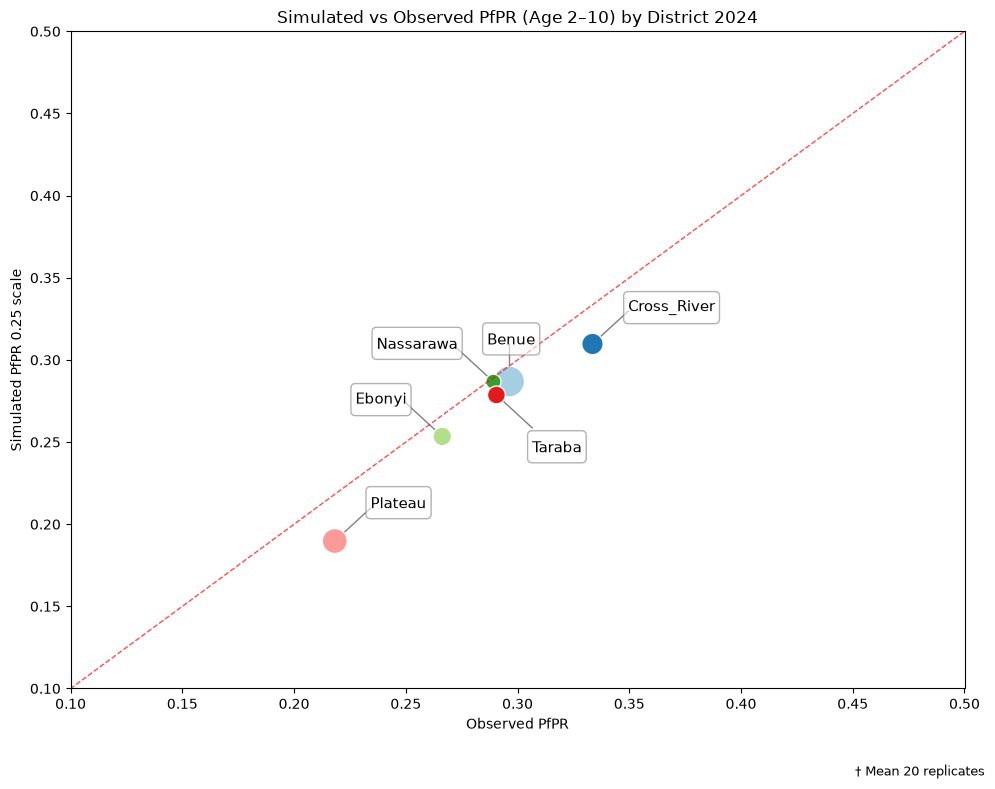

In [44]:
# ======================================================
# Figure 1: Simulated vs Observed PfPR by District
# ======================================================
fig, ax = plt.subplots(figsize=(10, 8))

d1 = compare_data[["mean_2_to_10_obs", "mean_2_to_10_sim", "State", "mean_population_sim"]].dropna(
    subset=["mean_2_to_10_obs", "mean_2_to_10_sim"]
)

sns.scatterplot(
    data=d1,
    x="mean_2_to_10_obs",
    y="mean_2_to_10_sim",
    hue="State",
    size="mean_population_sim",
    sizes=(120, 500),
    palette="Paired",
    ax=ax,
    legend=False
)

sc = ax.collections[0] if ax.collections else None

''' Use full range when trying to calibrate pipeline, narrow range yields better looking plots when finalized'''

# ax.set_xlim(0.0, 1.0)
# ax.set_ylim(0.0, 1.0)
ax.set_xlim(0.1, 0.5)
ax.set_ylim(0.1, 0.5)

span = min(ax.get_xlim()[1] - ax.get_xlim()[0], ax.get_ylim()[1] - ax.get_ylim()[0])

texts = d1["State"].astype(str).fillna("").tolist()
x = d1["mean_2_to_10_obs"].to_numpy(dtype=float)
y = d1["mean_2_to_10_sim"].to_numpy(dtype=float)

allocate(
    ax,
    x,
    y,
    texts,
    scatter_plot=sc,
    textsize=11,
    draw_lines=True,
    linecolor="gray",
    textcolor="black",
    margin=0.02,
    min_distance=0.10 * span,
    max_distance=0.35 * span,
    nbr_candidates=3000,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

ax.plot([0.0, 1.0], [0.0, 1.0], linestyle="--", linewidth=1, color="red", alpha=0.7)
ax.set_title(f"Simulated vs Observed PfPR (Age 2–10) by District {calibration_year}")
ax.set_xlabel("Observed PfPR")
ax.set_ylabel(f"Simulated PfPR {population_scale_from_input_yml} scale")

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.99, 0.02, f"$\dagger$ Mean {validation_replicates} replicates",
          ha='right', va='bottom', fontsize=9)
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_PfPR_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

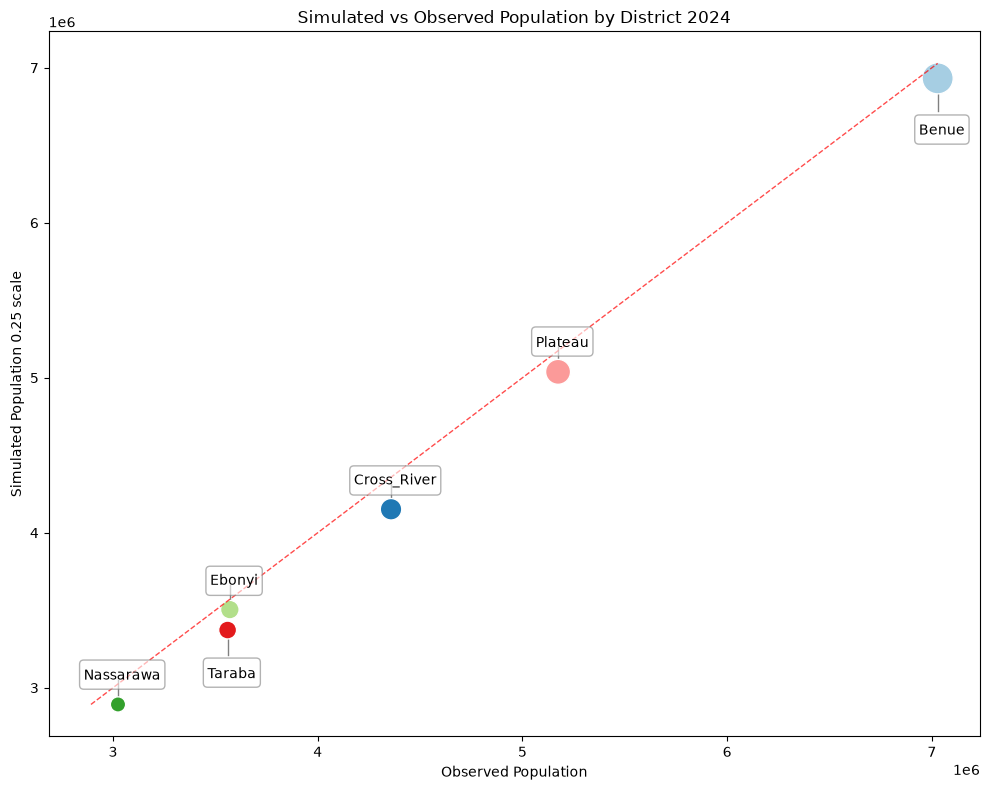

In [45]:
# ======================================================
# Figure 2: Simulated vs Observed Population by District
# ======================================================
fig, ax = plt.subplots(figsize=(10, 8))

d2 = compare_data[["population_obs", "mean_population_sim", "State"]].dropna(
    subset=["population_obs", "mean_population_sim"]
)

sns.scatterplot(
    data=d2,
    x="population_obs",
    y="mean_population_sim",
    hue="State",
    size="mean_population_sim",
    sizes=(120, 500),
    palette="Paired",
    ax=ax,
    legend=False
)

sc = ax.collections[0] if ax.collections else None

texts = d2["State"].astype(str).fillna("").tolist()
x = d2["population_obs"].to_numpy(dtype=float)
y = d2["mean_population_sim"].to_numpy(dtype=float)

allocate(
    ax,
    x,
    y,
    texts,
    scatter_plot=sc,
    textsize=10,
    draw_lines=True,
    linecolor="gray",
    textcolor="black",
    margin=0.01,
    min_distance=0.01,
    max_distance=0.08,
    nbr_candidates=300,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

min_val = min(d2["population_obs"].min(), d2["mean_population_sim"].min())
max_val = max(d2["population_obs"].max(), d2["mean_population_sim"].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1, color="red", alpha=0.7)

ax.set_title(f"Simulated vs Observed Population by District {calibration_year}")
ax.set_xlabel("Observed Population")
ax.set_ylabel(f"Simulated Population {population_scale_from_input_yml} scale")

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_Population_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

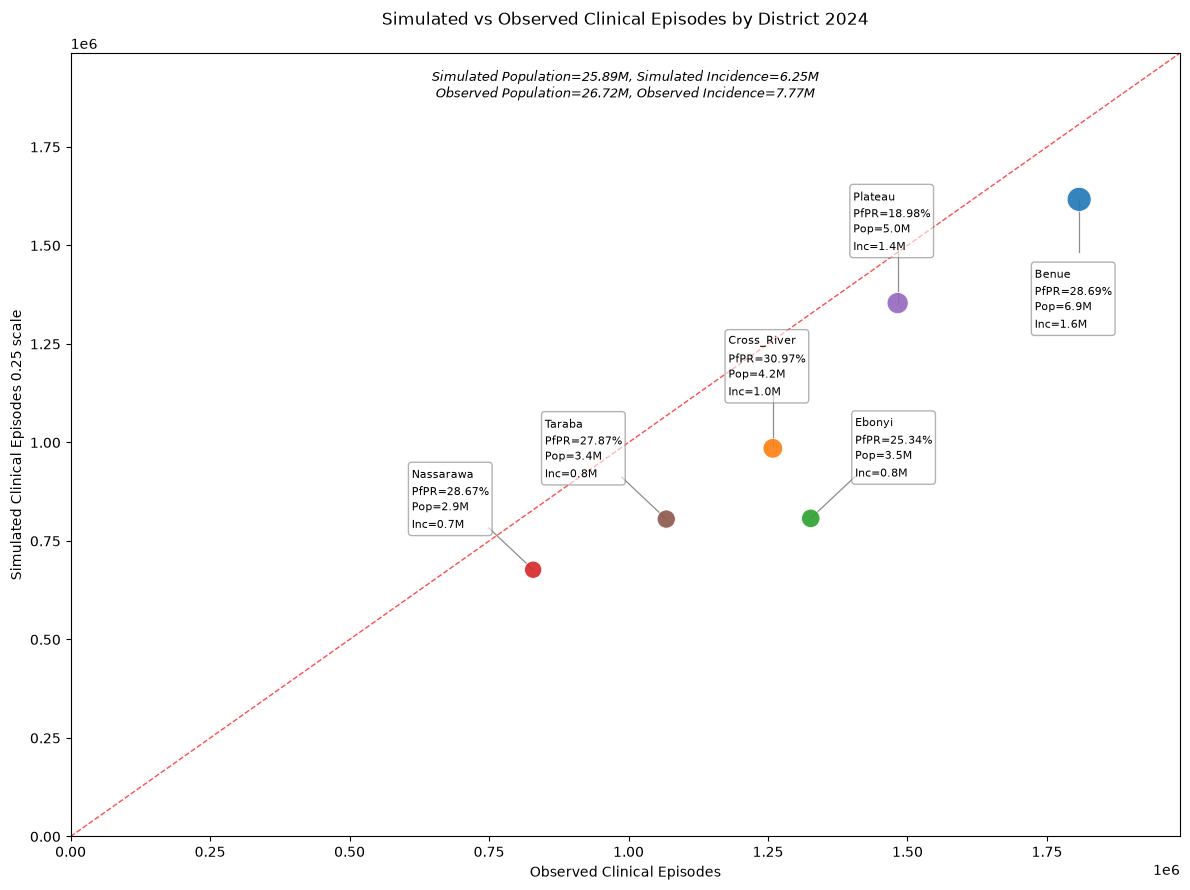

In [46]:
# ======================================================
# Figure 3: Simulated vs Observed Clinical Episodes by District
# ======================================================
fig, ax = plt.subplots(figsize=(12, 9))

d4 = compare_data[
    [
        "annual_clinical_episodes_obs",
        # "mean_clinical_episodes_sim",
        "adjusted_mean_clinical_episodes_sim",
        "mean_population_sim",
        "State",
        "mean_2_to_10_sim",
        "population_obs"
    ]
].dropna(
    subset=[
        "annual_clinical_episodes_obs",
        # "mean_clinical_episodes_sim",
        "adjusted_mean_clinical_episodes_sim",
        "mean_population_sim",
        "mean_2_to_10_sim",
        "population_obs"
    ]
).copy()

x = d4["annual_clinical_episodes_obs"].to_numpy(float)
# y = d4["mean_clinical_episodes_sim"].to_numpy(float)
y = d4["adjusted_mean_clinical_episodes_sim"].to_numpy(float)

pop = d4["mean_population_sim"].to_numpy(float)
sizes = (pop / pop.max()) * 250.0 + 50.0

total_pop_sim = d4["mean_population_sim"].sum()
# total_clinical_episodes_sim = d4["mean_clinical_episodes_sim"].sum()
total_clinical_episodes_sim = d4["adjusted_mean_clinical_episodes_sim"].sum()
total_pop_obs = d4["population_obs"].sum()
total_clinical_episodes_obs = d4["annual_clinical_episodes_obs"].sum()

texts = []
for _, row in d4.iterrows():
    name = str(row["State"])
    pfpr = row["mean_2_to_10_sim"]
    population = row["mean_population_sim"]
    # cases = row["mean_clinical_episodes_sim"]
    cases = row["adjusted_mean_clinical_episodes_sim"]
    label = f"{name}\nPfPR={pfpr*100:.2f}%\nPop={population/1e6:.1f}M\nInc={cases/1e6:.1f}M"
    texts.append(label)

districts = d4["State"].astype(str).tolist()
palette = sns.color_palette("tab10", n_colors=len(districts))
color_map = {name: palette[i] for i, name in enumerate(districts)}
colors = [color_map[name] for name in districts]

sc = ax.scatter(
    x, y,
    s=sizes,
    c=colors,
    alpha=0.9,
    edgecolors="white",
    linewidths=0.6,
    zorder=2,
)

maxv = max(np.nanmax(x), np.nanmax(y)) * 1.10
ax.set_xlim(0, maxv)
ax.set_ylim(0, maxv)

linecolor = [(0, 0, 0, 0.45)] * len(x)

allocate(
    ax, x, y, texts,
    scatter_plot=sc,
    textsize=8,
    draw_lines=True,
    draw_all=True,
    linecolor=linecolor,
    linewidth=0.9,
    margin=0.03,
    min_distance=0.04,
    max_distance=0.38,
    nbr_candidates=5000,
    verbose=False,
    linespacing=1.5,   
    multialignment="left",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="gray",
        alpha=0.6,
    ),
)

ax.plot(ax.get_xlim(), ax.get_ylim(), color="red", linestyle="--", linewidth=1, zorder=1, alpha=0.7)
ax.set_xlabel("Observed Clinical Episodes")
ax.set_ylabel(f"Simulated Clinical Episodes {population_scale_from_input_yml} scale")
ax.set_title(
    f"Simulated vs Observed Clinical Episodes by District {calibration_year}\n"
)

ax.text(
    0.5, 0.98,
    f"Simulated Population={total_pop_sim/1e6:.2f}M, Simulated Incidence={total_clinical_episodes_sim/1e6:.2f}M\n"
    f"Observed Population={total_pop_obs/1e6:.2f}M, Observed Incidence={total_clinical_episodes_obs/1e6:.2f}M",
    transform=ax.transAxes,
    fontsize=9, color="black", style="italic",
    ha="center", va="top"
)

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_Clinical_Episodes_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()

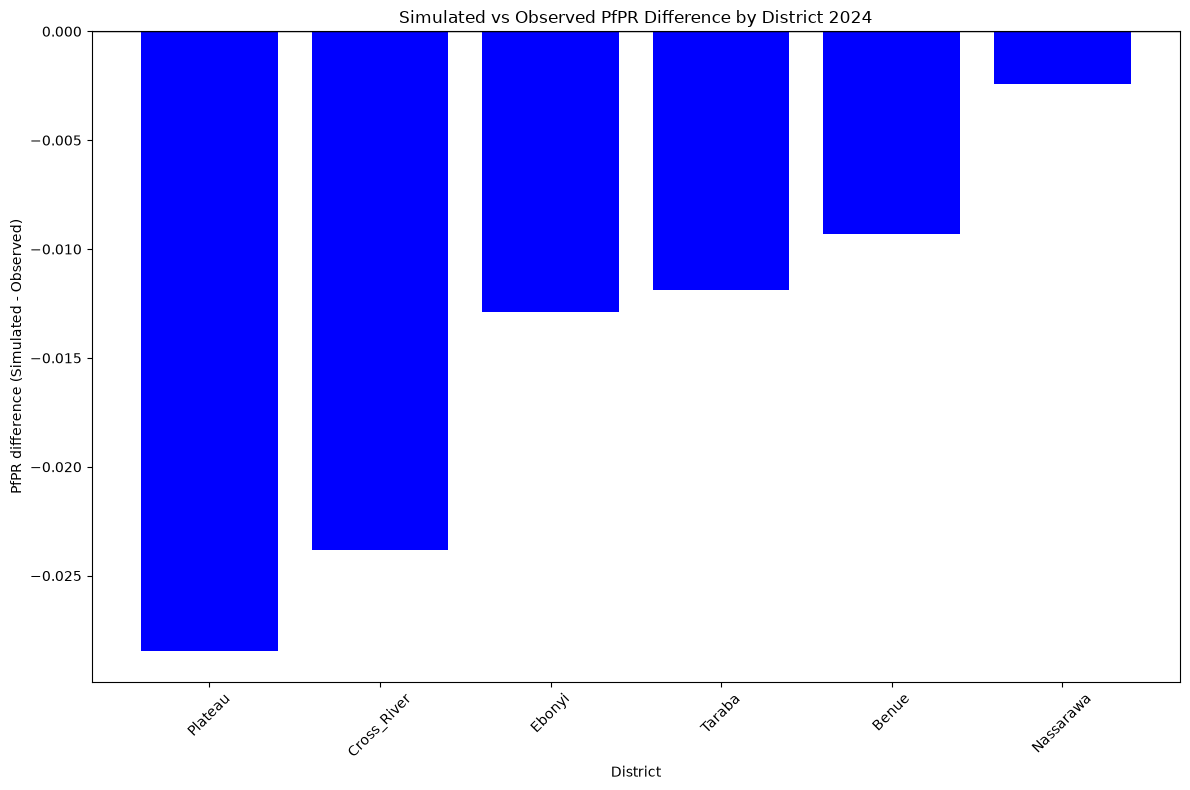

In [47]:
# ======================================================
# Figure 4: Simulated vs Observed PfPR difference by district
# ======================================================
fig, ax = plt.subplots(figsize=(12, 8))

d3 = compare_data.copy()
d3["diff"] = d3["mean_2_to_10_sim"] - d3["mean_2_to_10_obs"]
d3 = d3.sort_values("diff")

colors = ["red" if d > 0 else "blue" for d in d3["diff"]]

ax.bar(d3["State"].astype(str), d3["diff"], color=colors)
ax.axhline(0, color="black", linewidth=1)

ax.set_xlabel("District")
ax.set_ylabel("PfPR difference (Simulated - Observed)")
ax.set_title(f"Simulated vs Observed PfPR Difference by District {calibration_year}")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{analysis_path}/Simulated_vs_Observed_PfPR_Difference_by_District_{calibration_year}.png", dpi=200, bbox_inches="tight")
plt.show()